# Loading, cleaning and displaying gas exchange data

This is an example of how to load, clean and display gas exchange data from a Licor-6800 file. \
More information about the symbols can be found here: \
https://www.licor.com/support/LI-6800/topics/symbols.html#GasEx

Load some libraries for data processing and plotting.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Optional: Set the style for prettier plots
plt.style.use('seaborn-v0_8-whitegrid')

This function reads the data while accounting for the data structure.

In [2]:
def load_gas_exchange_file(filepath):
    """
    Parses the custom text file, skips the header, deduplicates column names, 
    and extracts the data.
    """
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()
        
    data_idx = -1
    for i, line in enumerate(lines):
        if line.strip() == '[Data]':
            data_idx = i
            break
            
    if data_idx == -1:
        print(f"Skipping {filepath} - No '[Data]' tag found.")
        return None
        
    # Extract raw column names
    raw_col_names = lines[data_idx + 2].strip('\n').split('\t')
    
    # Deduplicate column names (e.g., turn duplicate "TIME" into "TIME_1")
    col_names = []
    seen_names = {}
    
    for name in raw_col_names:
        # Handle trailing tabs which create empty strings
        if not name.strip():
            name = "Unnamed"
            
        if name in seen_names:
            seen_names[name] += 1
            col_names.append(f"{name}_{seen_names[name]}")
        else:
            seen_names[name] = 0
            col_names.append(name)
    
    # Read the data into a pandas DataFrame
    try:
        df = pd.read_csv(
            filepath, 
            sep='\t', 
            skiprows=data_idx + 4, 
            names=col_names, 
            index_col=False,
            engine='python' 
        )
        # Drop empty columns
        df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
        return df
    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return None

Here you can change the directory you want to load.
It loads all the data files of the directory into a dictionary. \
The data is cleaned by removing outliers or other problems. \
During self-calibration (detected by LeakPct > 1) the instrument continue to record but the data is not valid. \
Some cleaning steps are necessary to remove other types of invalid points (gsw values that are outside realistic values).

In [3]:
# Set your directory path here. Use '.' for the current directory.
DIRECTORY = 'Data/Training' 

# Define your quality control thresholds
leak_threshold = 1.0
gs_min = 0.0
gs_max = 0.6

data_dict = {}

# Iterate over files in the directory
for filename in os.listdir(DIRECTORY):
    filepath = os.path.join(DIRECTORY, filename)
    
    # Check if it's a file and has no extension
    if os.path.isfile(filepath) and '.' not in filename:
        df = load_gas_exchange_file(filepath)
        
        if df is not None and not df.empty:
            initial_len = len(df)
            
            # --- CLEANING STEP 1: LEAK ---
            if 'LeakPct' in df.columns:
                df['Leak'] = pd.to_numeric(df['LeakPct'], errors='coerce')
                df = df[df['Leak'] <= leak_threshold]
            else:
                print(f"Warning: 'LeakPct' column not found in {filename}.")
                
            # --- CLEANING STEP 2: STOMATAL CONDUCTANCE (gsw) ---
            gs_col = 'gsw' if 'gsw' in df.columns else ('gs' if 'gs' in df.columns else None)
            if gs_col:
                df[gs_col] = pd.to_numeric(df[gs_col], errors='coerce')
                df = df[(df[gs_col] >= gs_min) & (df[gs_col] <= gs_max)]
            else:
                print(f"Warning: Neither 'gsw' nor 'gs' column found in {filename}.")
            
            dropped_rows = initial_len - len(df)
            
            # Only add to dictionary if there's still data left after cleaning
            if not df.empty:
                data_dict[filename] = df
                print(f"Loaded & Cleaned: {filename} ({len(df)} rows kept, {dropped_rows} dropped).")
            else:
                print(f"Skipping {filename}: All rows were filtered out during cleaning.")

if not data_dict:
    print("No valid files found, or all data was filtered out.")

Loaded & Cleaned: 2023-08-25-1038_logdata_silvere2_flash (5642 rows kept, 46 dropped).


Loaded & Cleaned: 2023-08-30-1101_logdata_silvere2_flash (5638 rows kept, 33 dropped).


Loaded & Cleaned: 2023-09-06-1204_logdata_silvere2_flash (5655 rows kept, 30 dropped).


Loaded & Cleaned: 2023-09-22-1242_logdata_silvere2_flash (5598 rows kept, 44 dropped).


Loaded & Cleaned: 2023-10-24-1257_logdata_silvere2_flash (5602 rows kept, 67 dropped).


Loaded & Cleaned: 2023-10-24-1300_logdata2_silvere2_flash (5538 rows kept, 30 dropped).


Display the cleaned data. You can visually inspect the data and start thinking about a model :-D

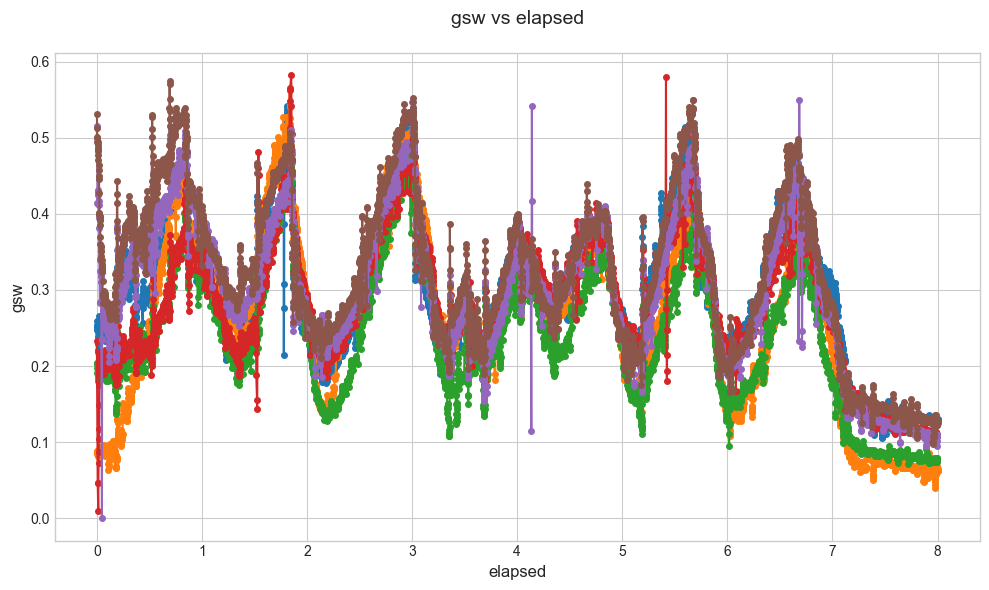

In [4]:
# Define which columns to plot
x_col = 'elapsed'
y_col = 'gsw'

plt.figure(figsize=(10, 6))

for filename, df in data_dict.items():
    if x_col in df.columns and y_col in df.columns:
        
        # Convert plotting columns to numeric (just in case)
        x_data = pd.to_numeric(df[x_col], errors='coerce')
        y_data = pd.to_numeric(df[y_col], errors='coerce')
        
        # Plot the pre-cleaned data
        plt.plot(x_data/3600, y_data, marker='o', linestyle='-', markersize=4, label=filename)
    else:
        print(f"Warning: Columns '{x_col}' or '{y_col}' not found in {filename}.")

# We can still reference the thresholds in the title since they were defined in Cell 3
plt.title(f'{y_col} vs {x_col}\n', fontsize=14)
plt.xlabel(f'{x_col}', fontsize=12)
plt.ylabel(f'{y_col}', fontsize=12)
#plt.legend(title="Files", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Model-Based Stomatal Conductance Prototype

This section adds a model-based prototype for predicting stomatal conductance (`gsw`) from LI-6800 environmental variables.

The earlier notebook cells load, clean, and explore the data. Those cells are intentionally left unchanged. The modelling code below creates separate modelling copies of the Training and Validation data so that the original `data_dict` is not overwritten.

The target variable is `gsw`. The candidate predictors are environmental and chamber variables:

- `Qin`: incoming light intensity
- `Ca`: ambient CO2 concentration
- `VPDleaf`: leaf vapour pressure deficit
- `Tleaf`: leaf temperature
- `Tair`: air temperature
- `RHcham`: chamber relative humidity

Measured `A` is **not** used as an input to predict `gsw`. It is only kept for evaluation, because using measured assimilation directly would leak information from the plant response into the stomatal conductance model. Instead, assimilation is simulated as an intermediate variable using a simple light-response function.

## Modelling Rationale

A model-based approach was selected because stomatal conductance is not just a statistical response to one variable. It is biologically linked to light, CO2, vapour pressure deficit, and photosynthetic demand.

`Qin`, `Ca`, and `VPDleaf` are especially meaningful:

- Light (`Qin`) drives photosynthesis and stomatal opening.
- Ambient CO2 (`Ca`) affects the CO2 gradient and stomatal regulation.
- Vapour pressure deficit (`VPDleaf`) represents atmospheric water demand; stomata often close when VPD increases.

The Leuning-type model was selected as the main literature-based prototype because it links stomatal conductance to assimilation, CO2 concentration, and VPD. In this notebook, assimilation is simulated rather than taken from measured `A`.

## Models Implemented

**Model 0: simple empirical baseline**

Uses only light and VPD:

```text
gsw_pred = g0 + a * Qin / (Kq + Qin) * 1 / (1 + VPDleaf / D0)
```

**Model 1: Leuning 1995 model with simulated photosynthesis**

First simulates assimilation:

```text
A_model = (Amax * Qin) / (K + Qin) - Rd
```

Then predicts stomatal conductance:

```text
gsw_pred = g0 + gL * A_model / ((1 + VPDleaf / D0) * (Ca - Gamma))
```

**Model 2: dynamic Leuning model with stomatal time lag**

First calculates the Leuning target, then applies a lag:

```text
gsw_dynamic[t] = gsw_dynamic[t-1] + k_lag * (gsw_target[t] - gsw_dynamic[t-1])
```

Training data are used for parameter fitting only. Validation data are kept separate and used only for final evaluation.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import least_squares
from IPython.display import display

MODEL_COLUMNS = ["gsw", "Qin", "Ca", "VPDleaf", "Tleaf", "Tair", "RHcham", "A", "elapsed"]


def remove_gsw_spikes(df, gsw_col="gsw", window=21, threshold=0.08):
    """Remove isolated gsw spikes using a centered rolling median filter."""
    if gsw_col not in df.columns:
        return df.copy()

    filtered_df = df.copy()
    gsw = pd.to_numeric(filtered_df[gsw_col], errors="coerce")
    rolling_median = gsw.rolling(window=window, center=True, min_periods=5).median()
    deviation = (gsw - rolling_median).abs()
    keep = rolling_median.isna() | (deviation <= threshold)
    return filtered_df[keep].copy()


def prepare_model_data(df):
    """Create a modelling copy with numeric variables and modelling-specific filters."""
    model_df = df.copy()

    for col in MODEL_COLUMNS:
        if col in model_df.columns:
            model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

    required = ["gsw", "Qin", "Ca", "VPDleaf", "Tleaf", "Tair", "RHcham", "A"]
    model_df = model_df.dropna(subset=required)

    model_df = model_df[
        (model_df["gsw"].between(0, 0.6))
        & (model_df["Qin"] >= 0)
        & (model_df["Ca"].between(300, 500))
        & (model_df["VPDleaf"].between(0, 5))
        & (model_df["Tleaf"].between(10, 45))
    ].copy()

    return model_df.reset_index(drop=True)


def combine_data_dict(data_dict):
    """Combine a dictionary of dataframes and preserve the source file name."""
    frames = []
    for filename, df in data_dict.items():
        temp = df.copy()
        temp["_file"] = filename
        frames.append(temp)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


def load_clean_folder_for_model(directory):
    """Load files from one folder using the existing parser, then apply the same early QC rules."""
    model_data_dict = {}

    for filename in sorted(os.listdir(directory)):
        filepath = os.path.join(directory, filename)
        if os.path.isfile(filepath) and "." not in filename:
            df = load_gas_exchange_file(filepath)

            if df is None or df.empty:
                continue

            df = df.copy()

            if "LeakPct" in df.columns:
                df["Leak"] = pd.to_numeric(df["LeakPct"], errors="coerce")
                df = df[df["Leak"] <= leak_threshold]

            if "gsw" in df.columns:
                df["gsw"] = pd.to_numeric(df["gsw"], errors="coerce")
                df = df[(df["gsw"] >= gs_min) & (df["gsw"] <= gs_max)]
                df = remove_gsw_spikes(df, gsw_col="gsw", window=21, threshold=0.08)

            if not df.empty:
                model_data_dict[filename] = df

    return model_data_dict


training_model_dict = load_clean_folder_for_model("Data/Training")
validation_model_dict = load_clean_folder_for_model("Data/Validation")

train_df_raw = combine_data_dict(training_model_dict)
validation_df_raw = combine_data_dict(validation_model_dict)

train_df = prepare_model_data(train_df_raw)
validation_df = prepare_model_data(validation_df_raw)

print(f"Training rows for modelling: {len(train_df):,}")
print(f"Validation rows for modelling: {len(validation_df):,}")
print(f"Training files: {train_df['_file'].nunique() if '_file' in train_df else 0}")
print(f"Validation files: {validation_df['_file'].nunique() if '_file' in validation_df else 0}")

display(train_df[["gsw", "Qin", "Ca", "VPDleaf", "Tleaf", "Tair", "RHcham", "A"]].describe().T)

Training rows for modelling: 33,565
Validation rows for modelling: 27,646
Training files: 6
Validation files: 5


,count,mean,std,min,25%,50%,75%,max
gsw,33565.0,0.285430,0.101373,0.039548,0.220648,0.285077,0.356154,0.562059
Qin,33565.0,593.642938,580.256750,0.019997,50.059700,349.427000,1199.910000,1750.260000
Ca,33565.0,395.127729,3.818598,313.974000,391.451000,395.175000,398.990999,400.888000
VPDleaf,33565.0,0.890239,0.068808,0.706930,0.839929,0.881130,0.933013,1.167149
Tleaf,33565.0,22.423711,0.430726,21.109700,22.111700,22.379200,22.697400,24.100000
Tair,33565.0,22.995279,0.043359,22.637200,22.982600,22.993300,23.007400,23.276800
RHcham,33565.0,65.040424,0.203173,56.776426,64.928103,65.035220,65.151444,67.430710
A,33565.0,11.212564,9.318704,-3.846238,1.629810,11.111166,20.215891,197.882202


## Model Functions

The functions below implement the three requested models.

Parameter meanings:

| Parameter | Meaning |
|---|---|
| `g0` | residual/minimum stomatal conductance |
| `a` | empirical maximum response scale for Model 0 |
| `Kq` | half-saturation constant for light in Model 0 |
| `Amax` | maximum simulated assimilation rate |
| `K` | half-saturation constant for the photosynthesis light response |
| `Rd` | dark respiration term subtracted from simulated assimilation |
| `gL` | Leuning stomatal sensitivity coefficient |
| `Gamma` | CO2 compensation-point-like parameter |
| `D0` | VPD sensitivity parameter |
| `k_lag` | stomatal adjustment rate for the dynamic model |

In [6]:
def photosynthesis_light_response(Qin, Amax, K, Rd):
    """Simulate assimilation from light only. Measured A is not used here."""
    Qin = np.asarray(Qin, dtype=float)
    return (Amax * Qin) / (K + Qin + 1e-9) - Rd


def empirical_light_vpd_model(Qin, VPDleaf, params):
    """Model 0: empirical light and VPD response."""
    g0, a, Kq, D0 = params
    Qin = np.asarray(Qin, dtype=float)
    VPDleaf = np.asarray(VPDleaf, dtype=float)
    return g0 + a * Qin / (Kq + Qin + 1e-9) * 1 / (1 + VPDleaf / D0)


def leuning_1995_model(Qin, Ca, VPDleaf, params):
    """Model 1: Leuning-style model using simulated photosynthesis."""
    Amax, K, Rd, g0, gL, Gamma, D0 = params
    A_model = photosynthesis_light_response(Qin, Amax, K, Rd)
    denominator = (1 + np.asarray(VPDleaf, dtype=float) / D0) * (np.asarray(Ca, dtype=float) - Gamma)
    return g0 + gL * A_model / (denominator + 1e-9)


def dynamic_leuning_model(df, params):
    """Model 2: Leuning target with a first-order stomatal time lag, reset by file."""
    Amax, K, Rd, g0, gL, Gamma, D0, k_lag = params
    target_params = [Amax, K, Rd, g0, gL, Gamma, D0]

    output = pd.Series(index=df.index, dtype=float)
    groups = df.groupby("_file", sort=False) if "_file" in df.columns else [(None, df)]

    for _, group in groups:
        target = leuning_1995_model(group["Qin"], group["Ca"], group["VPDleaf"], target_params)
        target = np.asarray(target, dtype=float)

        dynamic = np.empty_like(target)
        if len(target) == 0:
            continue

        dynamic[0] = np.clip(group["gsw"].iloc[0], 0, 0.6)
        for i in range(1, len(target)):
            dynamic[i] = dynamic[i - 1] + k_lag * (target[i] - dynamic[i - 1])

        output.loc[group.index] = dynamic

    return output.to_numpy()


def predict_model(model_name, params, df):
    if model_name == "Model 0":
        return empirical_light_vpd_model(df["Qin"], df["VPDleaf"], params)
    if model_name == "Model 1":
        return leuning_1995_model(df["Qin"], df["Ca"], df["VPDleaf"], params)
    if model_name == "Model 2":
        return dynamic_leuning_model(df, params)
    raise ValueError(f"Unknown model: {model_name}")


def calculate_metrics(y_obs, y_pred):
    y_obs = np.asarray(y_obs, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_obs) & np.isfinite(y_pred)
    y_obs = y_obs[mask]
    y_pred = y_pred[mask]

    residual = y_obs - y_pred
    rmse = np.sqrt(np.mean(residual ** 2))
    bias = np.mean(y_pred - y_obs)
    ss_res = np.sum(residual ** 2)
    ss_tot = np.sum((y_obs - np.mean(y_obs)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    return {"RMSE": rmse, "R2": r2, "Bias": bias}

## Dynamic Model Initial State

The dynamic models require an initial state. Therefore, the first observed gsw value of each file was used only as the initial condition. After initialization, observed gsw was not used as an input; predictions were generated from environmental variables, A_model, and fixed fitted parameters.


## Parameter Fitting

Parameters are fitted only on the Training dataset. The Validation dataset is not used during fitting.

The fitted models are then evaluated on both Training and Validation to check whether performance transfers to unseen files.

In [7]:
PARAMETER_BOUNDS = {
    "Model 0": {
        "names": ["g0", "a", "Kq", "D0"],
        "lower": [0, 0, 1, 0.01],
        "upper": [0.1, 5, 3000, 10],
        "initial": [0.02, 1.0, 300, 1.5],
    },
    "Model 1": {
        "names": ["Amax", "K", "Rd", "g0", "gL", "Gamma", "D0"],
        "lower": [0, 1, 0, 0, 0, 0, 0.01],
        "upper": [50, 3000, 10, 0.1, 50, 100, 10],
        "initial": [30, 500, 2, 0.02, 10, 40, 1.5],
    },
    "Model 2": {
        "names": ["Amax", "K", "Rd", "g0", "gL", "Gamma", "D0", "k_lag"],
        "lower": [0, 1, 0, 0, 0, 0, 0.01, 0.001],
        "upper": [50, 3000, 10, 0.1, 50, 100, 10, 1],
        "initial": [30, 500, 2, 0.02, 10, 40, 1.5, 0.15],
    },
}


def fit_model(model_name, train_df):
    spec = PARAMETER_BOUNDS[model_name]
    y_obs = train_df["gsw"].to_numpy(dtype=float)

    def residuals(params):
        y_pred = predict_model(model_name, params, train_df)
        residual = y_pred - y_obs
        return np.nan_to_num(residual, nan=1e3, posinf=1e3, neginf=-1e3)

    result = least_squares(
        residuals,
        x0=np.asarray(spec["initial"], dtype=float),
        bounds=(np.asarray(spec["lower"], dtype=float), np.asarray(spec["upper"], dtype=float)),
        max_nfev=500,
        loss="soft_l1",
    )

    params = dict(zip(spec["names"], result.x))
    return params, result


def params_to_array(model_name, params):
    return np.asarray([params[name] for name in PARAMETER_BOUNDS[model_name]["names"]], dtype=float)


def evaluate_model(model_name, params, train_df, validation_df):
    param_array = params_to_array(model_name, params)
    rows = []

    for dataset_name, df in [("Training", train_df), ("Validation", validation_df)]:
        y_pred = predict_model(model_name, param_array, df)
        metrics = calculate_metrics(df["gsw"], y_pred)
        rows.append({"Model": model_name, "Dataset": dataset_name, **metrics})

    return pd.DataFrame(rows)


fitted_params = {}
fit_results = {}
metric_tables = []

for model_name in ["Model 0", "Model 1", "Model 2"]:
    params, result = fit_model(model_name, train_df)
    fitted_params[model_name] = params
    fit_results[model_name] = result
    metric_tables.append(evaluate_model(model_name, params, train_df, validation_df))

    print(f"\n{model_name} fitted parameters")
    for key, value in params.items():
        print(f"  {key}: {value:.6g}")
        
    print(f"  optimizer cost: {result.cost:.6g}")
    print(f"  function evaluations: {result.nfev}")

comparison_table = pd.concat(metric_tables, ignore_index=True)
comparison_table[["RMSE", "R2", "Bias"]] = comparison_table[["RMSE", "R2", "Bias"]].round(4)

print("\nModel comparison")
display(comparison_table)


Model 0 fitted parameters
  g0: 0.1
  a: 5
  Kq: 16.8769
  D0: 0.0430852
  optimizer cost: 114.249
  function evaluations: 45



Model 1 fitted parameters
  Amax: 50
  K: 14.7411
  Rd: 5.07384e-39
  g0: 0.1
  gL: 50
  Gamma: 100
  D0: 0.0246477
  optimizer cost: 112.585
  function evaluations: 58



Model 2 fitted parameters
  Amax: 50
  K: 996.055
  Rd: 8.11163e-21
  g0: 0.0804178
  gL: 50
  Gamma: 100
  D0: 0.0809577
  k_lag: 0.00605074
  optimizer cost: 33.0007
  function evaluations: 59

Model comparison


,Model,Dataset,RMSE,R2,Bias
0,Model 0,Training,0.0827,0.3341,-0.0086
1,Model 0,Validation,0.0925,0.3161,0.0005
2,Model 1,Training,0.0821,0.3439,-0.0083
3,Model 1,Validation,0.0918,0.3269,0.0008
4,Model 2,Training,0.0444,0.8083,-0.0006
5,Model 2,Validation,0.0676,0.6349,0.0110


## Model Plots

The plots below compare observed and predicted `gsw` for Training and Validation data.

For the time-series plots, each plot shows one representative file to keep the notebook readable.

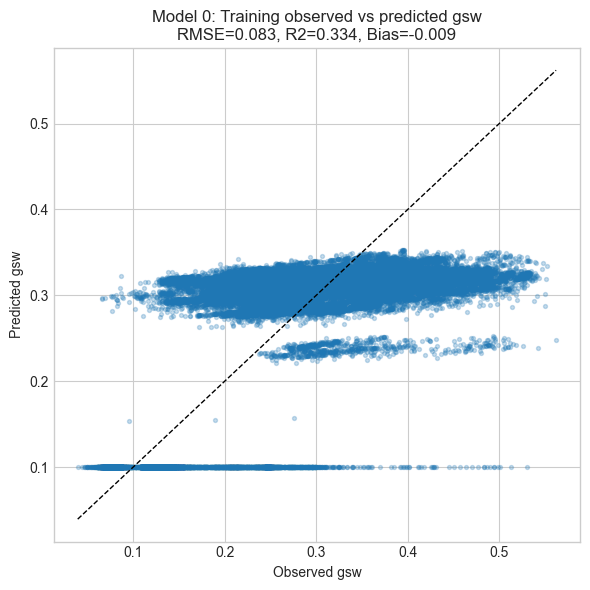

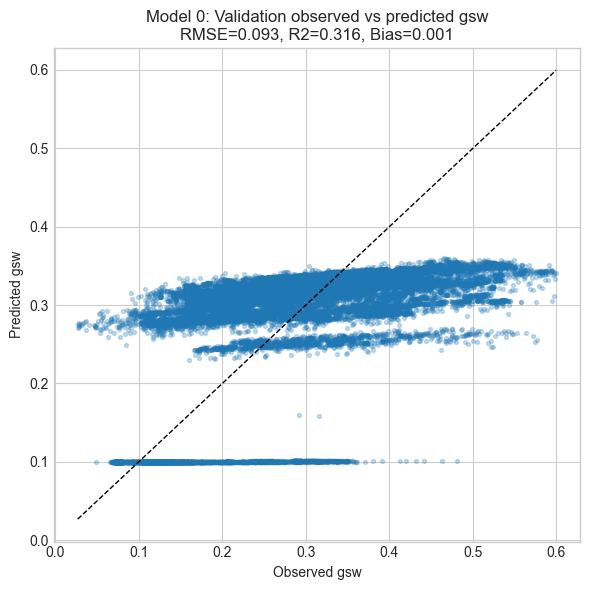

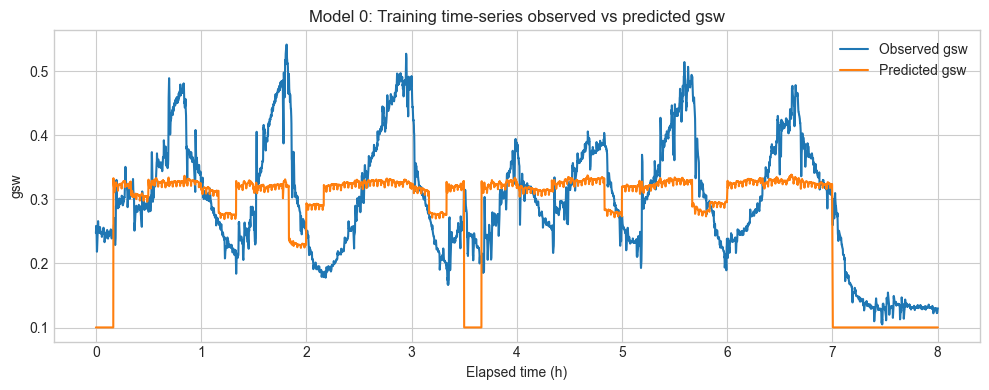

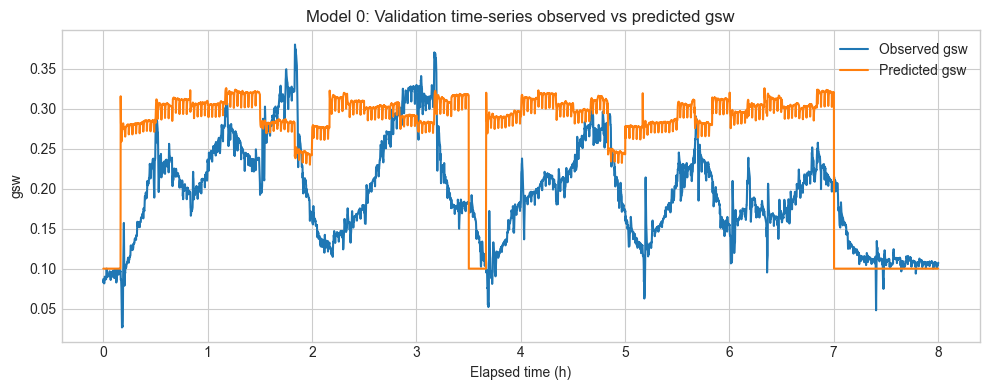

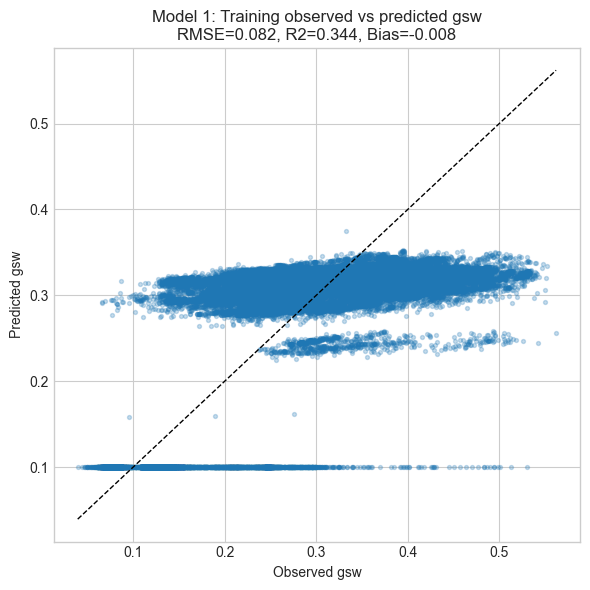

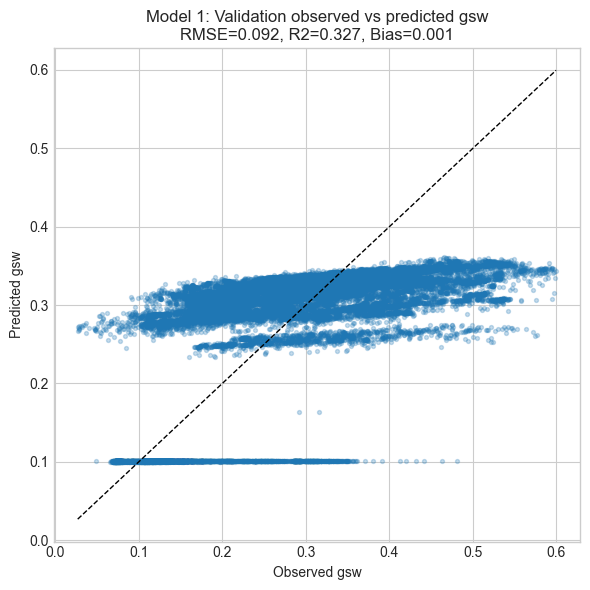

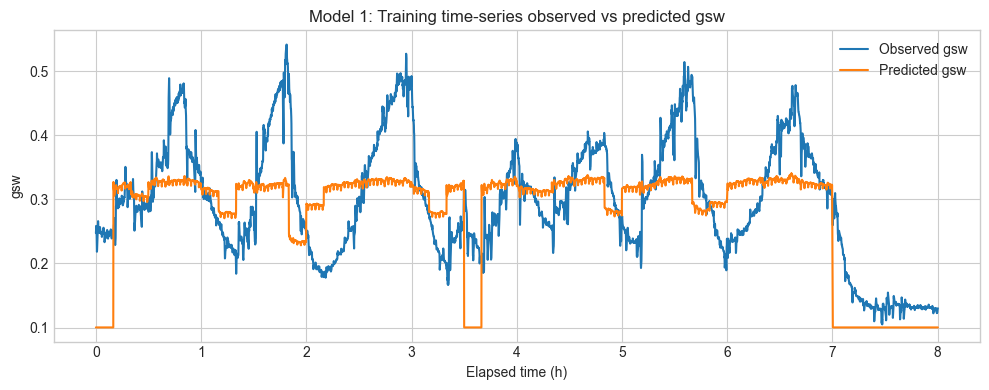

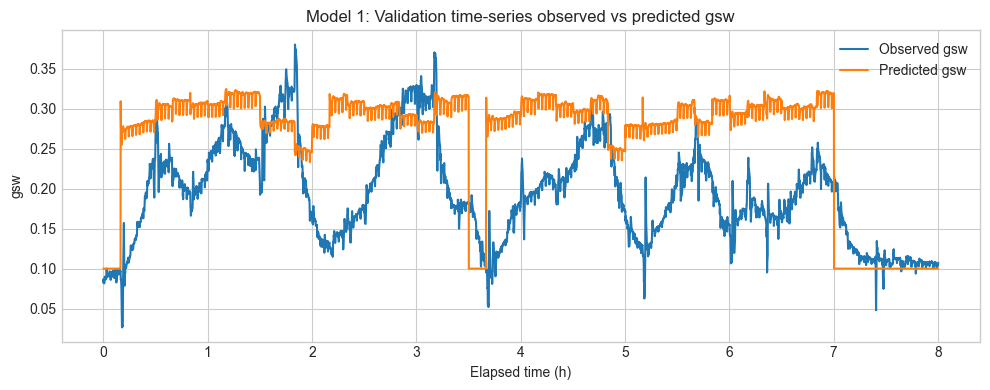

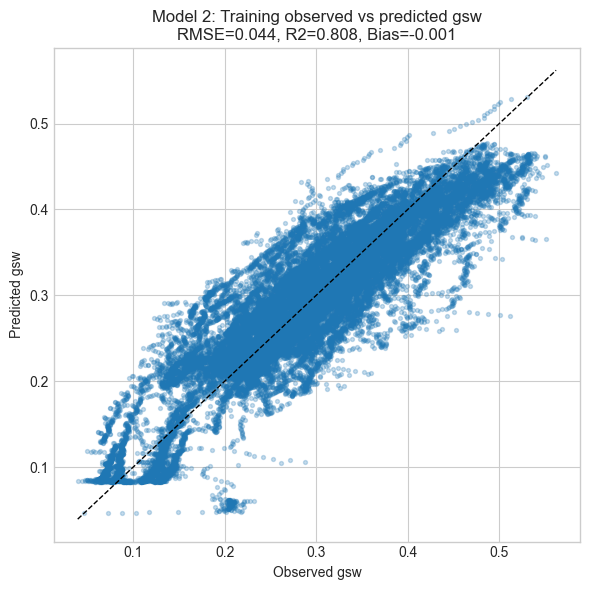

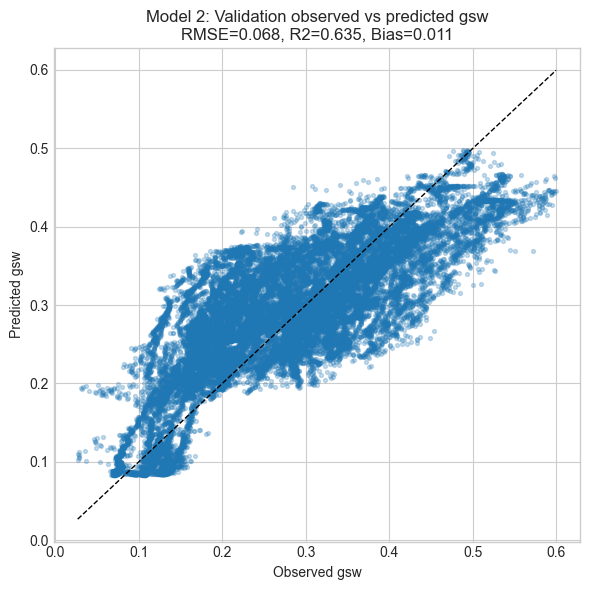

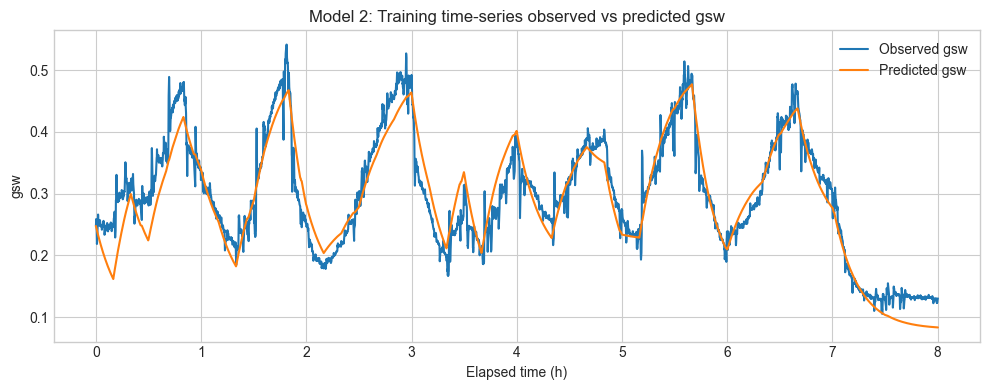

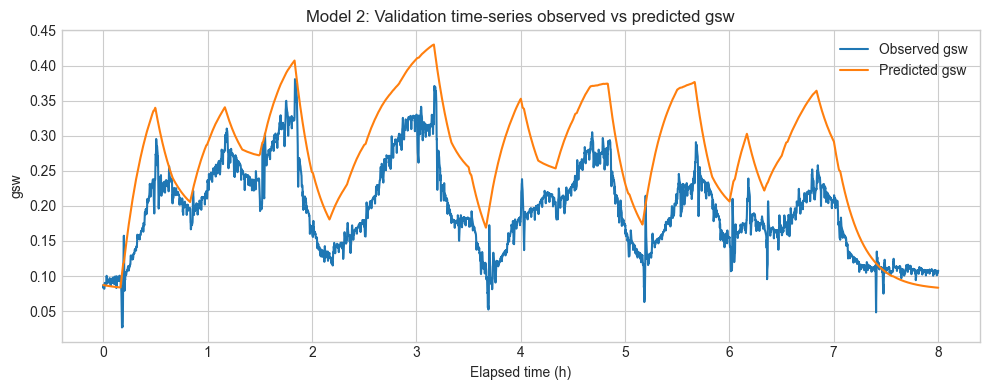

In [8]:
def plot_observed_vs_predicted(y_obs, y_pred, title):
    metrics = calculate_metrics(y_obs, y_pred)

    plt.figure(figsize=(6, 6))
    plt.scatter(y_obs, y_pred, s=8, alpha=0.25)
    lim_min = min(np.nanmin(y_obs), np.nanmin(y_pred))
    lim_max = max(np.nanmax(y_obs), np.nanmax(y_pred))
    plt.plot([lim_min, lim_max], [lim_min, lim_max], color="black", linestyle="--", linewidth=1)
    plt.xlabel("Observed gsw")
    plt.ylabel("Predicted gsw")
    plt.title(f"{title}\nRMSE={metrics['RMSE']:.3f}, R2={metrics['R2']:.3f}, Bias={metrics['Bias']:.3f}")
    plt.tight_layout()
    plt.show()


def plot_timeseries(df, y_pred, title):
    plot_df = df.copy()
    plot_df["gsw_pred"] = y_pred

    if "_file" in plot_df.columns:
        first_file = plot_df["_file"].iloc[0]
        plot_df = plot_df[plot_df["_file"] == first_file].copy()

    if "elapsed" in plot_df.columns:
        x = plot_df["elapsed"] / 3600
        xlabel = "Elapsed time (h)"
    else:
        x = np.arange(len(plot_df))
        xlabel = "Observation index"

    plt.figure(figsize=(10, 4))
    plt.plot(x, plot_df["gsw"], label="Observed gsw", linewidth=1.5)
    plt.plot(x, plot_df["gsw_pred"], label="Predicted gsw", linewidth=1.5)
    plt.xlabel(xlabel)
    plt.ylabel("gsw")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


predictions = {}

for model_name, params in fitted_params.items():
    param_array = params_to_array(model_name, params)
    predictions[(model_name, "Training")] = predict_model(model_name, param_array, train_df)
    predictions[(model_name, "Validation")] = predict_model(model_name, param_array, validation_df)

    plot_observed_vs_predicted(
        train_df["gsw"],
        predictions[(model_name, "Training")],
        f"{model_name}: Training observed vs predicted gsw",
    )
    plot_observed_vs_predicted(
        validation_df["gsw"],
        predictions[(model_name, "Validation")],
        f"{model_name}: Validation observed vs predicted gsw",
    )

    plot_timeseries(
        train_df,
        predictions[(model_name, "Training")],
        f"{model_name}: Training time-series observed vs predicted gsw",
    )
    plot_timeseries(
        validation_df,
        predictions[(model_name, "Validation")],
        f"{model_name}: Validation time-series observed vs predicted gsw",
    )

## Simulated A Compared With Measured A

Measured `A` is shown here only as an evaluation reference. It was **not** used as a model input for predicting `gsw`.

The Leuning models use `A_model`, which is simulated from `Qin` with a simple light-response equation.

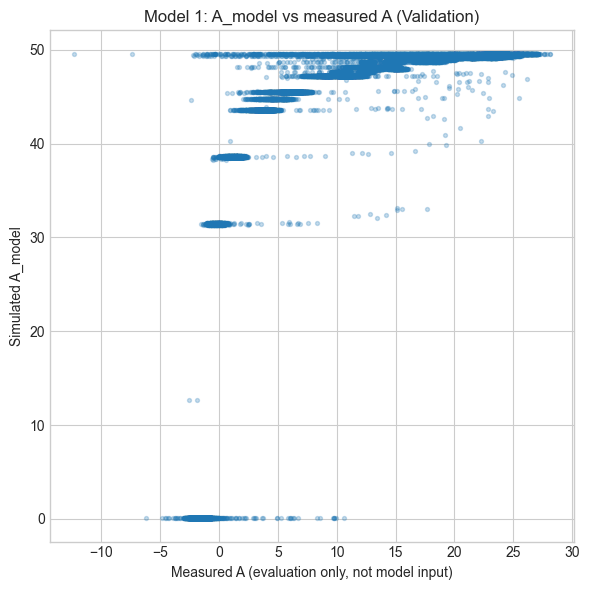

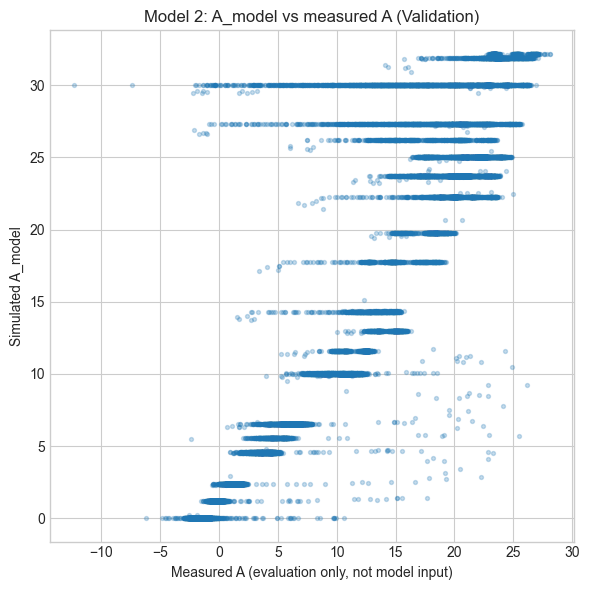

In [9]:
def plot_a_model_vs_measured(model_name, params, df, dataset_name="Validation"):
    param_array = params_to_array(model_name, params)
    Amax, K, Rd = param_array[:3]
    A_model = photosynthesis_light_response(df["Qin"], Amax, K, Rd)

    plt.figure(figsize=(6, 6))
    plt.scatter(df["A"], A_model, s=8, alpha=0.25)
    plt.xlabel("Measured A (evaluation only, not model input)")
    plt.ylabel("Simulated A_model")
    plt.title(f"{model_name}: A_model vs measured A ({dataset_name})")
    plt.tight_layout()
    plt.show()


plot_a_model_vs_measured("Model 1", fitted_params["Model 1"], validation_df)
plot_a_model_vs_measured("Model 2", fitted_params["Model 2"], validation_df)

## Sensitivity Analysis

The sensitivity analysis perturbs each fitted parameter of the main Leuning model by +10% and measures the change in Training RMSE.

This is a simple local sensitivity check, not a full global sensitivity analysis.

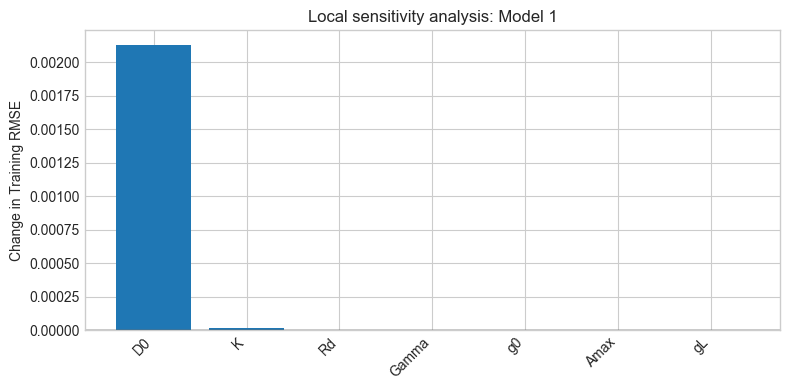

,Parameter,Delta_RMSE
6,D0,0.00213
1,K,0.00002
2,Rd,0.00000
5,Gamma,0.00000
3,g0,-0.00000
0,Amax,-0.00000
4,gL,-0.00000


In [10]:
def sensitivity_analysis(model_name, params, train_df):
    baseline_array = params_to_array(model_name, params)
    baseline_pred = predict_model(model_name, baseline_array, train_df)
    baseline_rmse = calculate_metrics(train_df["gsw"], baseline_pred)["RMSE"]

    spec = PARAMETER_BOUNDS[model_name]
    rows = []

    for i, name in enumerate(spec["names"]):
        perturbed = baseline_array.copy()
        if perturbed[i] == 0:
            perturbed[i] = 0.01
        else:
            perturbed[i] *= 1.10
        perturbed[i] = np.clip(perturbed[i], spec["lower"][i], spec["upper"][i])

        y_pred = predict_model(model_name, perturbed, train_df)
        rmse = calculate_metrics(train_df["gsw"], y_pred)["RMSE"]
        rows.append({"Parameter": name, "Delta_RMSE": rmse - baseline_rmse})

    sensitivity_df = pd.DataFrame(rows).sort_values("Delta_RMSE", ascending=False)

    plt.figure(figsize=(8, 4))
    plt.bar(sensitivity_df["Parameter"], sensitivity_df["Delta_RMSE"])
    plt.axhline(0, color="black", linewidth=1)
    plt.ylabel("Change in Training RMSE")
    plt.title(f"Local sensitivity analysis: {model_name}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return sensitivity_df


leuning_sensitivity = sensitivity_analysis("Model 1", fitted_params["Model 1"], train_df)
display(leuning_sensitivity.round(5))

## Model Limitations And Future Improvements

This prototype is intentionally simple and interpretable.

Main limitations:

- The photosynthesis component is a simple light-response curve, not a full biochemical photosynthesis model.
- The model does not explicitly include water stress, hydraulic limitation, or plant water potential.
- The dynamic stomatal lag model uses a single lag parameter for all files and all conditions.
- The current implementation treats each LI-6800 file as one time series and resets the dynamic state at the start of each file.
- Measured `A` is only used for evaluation; if `A_model` is poor, the Leuning `gsw` prediction will also be limited.

Possible future improvements:

- Replace the simple light-response `A_model` with a Farquhar photosynthesis model.
- Add a more detailed dynamic stomatal lag model with opening and closing rates.
- Include water stress or hydraulic variables if they become available.
- Fit parameters separately by genotype, treatment, or plant group if reliable metadata become available.
- Compare model-based predictions with machine-learning baselines while keeping measured `A` excluded from model inputs.

## Model 3: Asymmetric Dynamic Leuning Model

Model 3 extends the dynamic Leuning model by allowing separate response speeds for stomatal opening and closing. This is motivated by the fact that stomatal responses under fluctuating environmental conditions may deviate from steady-state assumptions. The model does not assume that opening is faster or slower than closing; instead, it estimates `k_open` and `k_close` from the training data.

The model structure is:

1. Simulate photosynthesis from light:

```text
A_model = (Amax * Qin) / (K + Qin) - Rd
```

2. Calculate the Leuning target conductance:

```text
gsw_target = g0 + gL * A_model / ((1 + VPDleaf / D0) * (Ca - Gamma))
```

3. Apply asymmetric stomatal dynamics:

```text
if gsw_target[t] > gsw_dynamic[t-1]:
    k = k_open
else:
    k = k_close

gsw_dynamic[t] = gsw_dynamic[t-1] + k * (gsw_target[t] - gsw_dynamic[t-1])
```

This optional model tests whether the data support different opening and closing response speeds.

In [11]:
MODEL_3_SPEC = {
    "names": ["Amax", "K", "Rd", "g0", "gL", "Gamma", "D0", "k_open", "k_close"],
    "lower": [0, 1, 0, 0, 0, 0, 0.01, 0.001, 0.001],
    "upper": [35, 3000, 10, 0.1, 50, 100, 10, 1, 1],
    "initial": [25, 500, 2, 0.02, 10, 40, 1.5, 0.15, 0.15],
}


def asymmetric_dynamic_leuning_model(df, params):
    """Model 3: Leuning target with separate opening and closing lag parameters."""
    Amax, K, Rd, g0, gL, Gamma, D0, k_open, k_close = params
    target_params = [Amax, K, Rd, g0, gL, Gamma, D0]

    output = pd.Series(index=df.index, dtype=float)
    groups = df.groupby("_file", sort=False) if "_file" in df.columns else [(None, df)]

    for _, group in groups:
        target = leuning_1995_model(group["Qin"], group["Ca"], group["VPDleaf"], target_params)
        target = np.asarray(target, dtype=float)

        dynamic = np.empty_like(target)
        if len(target) == 0:
            continue

        dynamic[0] = np.clip(group["gsw"].iloc[0], 0, 0.6)
        for i in range(1, len(target)):
            if target[i] > dynamic[i - 1]:
                k = k_open
            else:
                k = k_close
            dynamic[i] = dynamic[i - 1] + k * (target[i] - dynamic[i - 1])

        output.loc[group.index] = dynamic

    return output.to_numpy()


def fit_model_3_asymmetric_dynamic(train_df):
    """Fit Model 3 parameters on Training data only."""
    y_obs = train_df["gsw"].to_numpy(dtype=float)

    def residuals(params):
        y_pred = asymmetric_dynamic_leuning_model(train_df, params)
        residual = y_pred - y_obs
        return np.nan_to_num(residual, nan=1e3, posinf=1e3, neginf=-1e3)

    result = least_squares(
        residuals,
        x0=np.asarray(MODEL_3_SPEC["initial"], dtype=float),
        bounds=(np.asarray(MODEL_3_SPEC["lower"], dtype=float), np.asarray(MODEL_3_SPEC["upper"], dtype=float)),
        max_nfev=700,
        loss="soft_l1",
    )

    params = dict(zip(MODEL_3_SPEC["names"], result.x))
    return params, result


def model_3_params_to_array(params):
    return np.asarray([params[name] for name in MODEL_3_SPEC["names"]], dtype=float)


def evaluate_model_3(params, train_df, validation_df):
    param_array = model_3_params_to_array(params)
    rows = []

    for dataset_name, df in [("Training", train_df), ("Validation", validation_df)]:
        y_pred = asymmetric_dynamic_leuning_model(df, param_array)
        metrics = calculate_metrics(df["gsw"], y_pred)
        rows.append({"Model": "Model 3", "Dataset": dataset_name, **metrics})

    return pd.DataFrame(rows)


model_3_params, model_3_result = fit_model_3_asymmetric_dynamic(train_df)
model_3_metrics = evaluate_model_3(model_3_params, train_df, validation_df)

print("Model 3 fitted parameters")
for key, value in model_3_params.items():
    print(f"  {key}: {value:.6g}")
print(f"  optimizer cost: {model_3_result.cost:.6g}")
print(f"  function evaluations: {model_3_result.nfev}")

print("\nModel 3 metrics")
display(model_3_metrics.round(4))

Model 3 fitted parameters
  Amax: 35
  K: 1043.5
  Rd: 3.62938e-20
  g0: 0.0937135
  gL: 50
  Gamma: 100
  D0: 0.132271
  k_open: 0.00454815
  k_close: 0.00711542
  optimizer cost: 32.6102
  function evaluations: 49

Model 3 metrics


,Model,Dataset,RMSE,R2,Bias
0,Model 3,Training,0.0441,0.8105,-0.0008
1,Model 3,Validation,0.0686,0.6237,0.0122


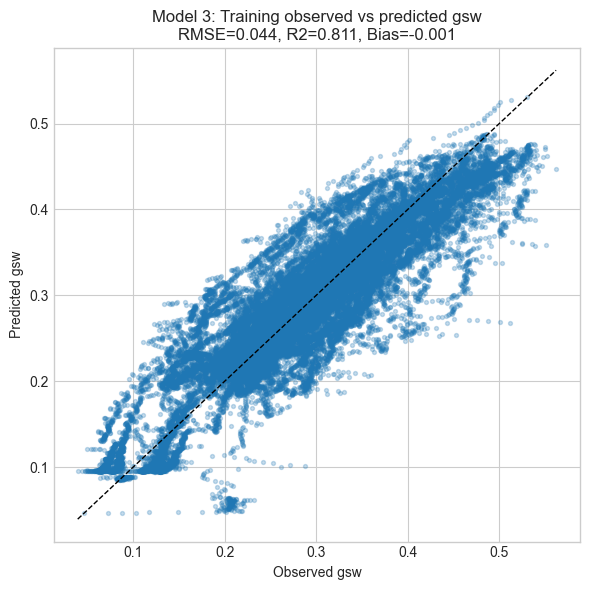

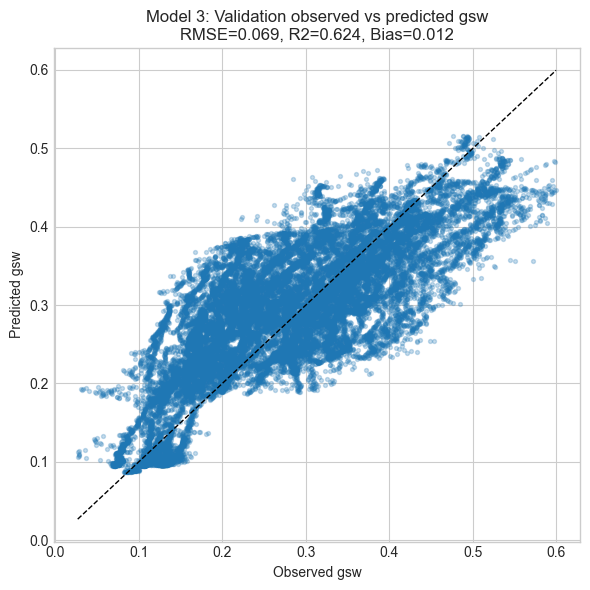

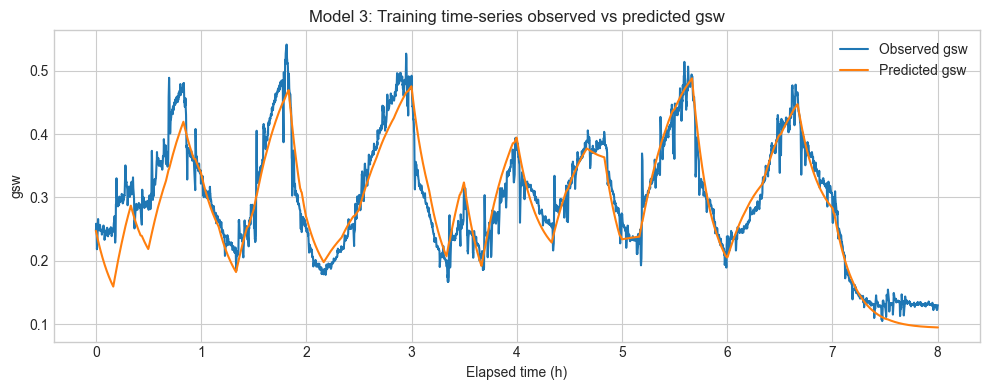

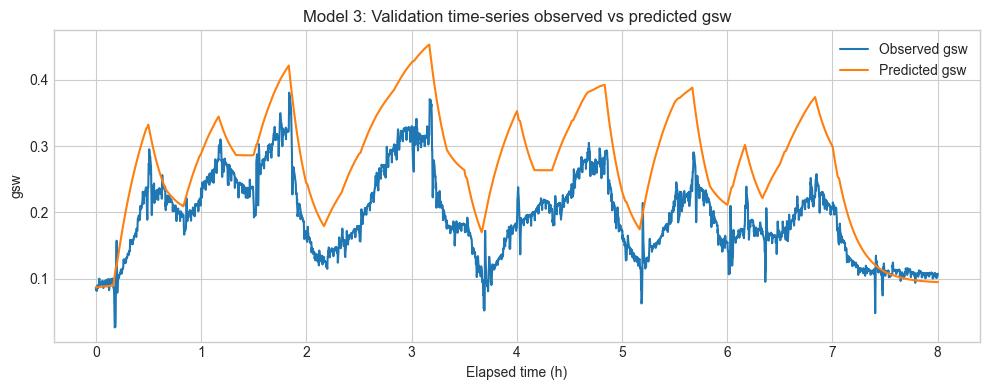

In [12]:
model_3_array = model_3_params_to_array(model_3_params)
model_3_train_pred = asymmetric_dynamic_leuning_model(train_df, model_3_array)
model_3_validation_pred = asymmetric_dynamic_leuning_model(validation_df, model_3_array)

plot_observed_vs_predicted(
    train_df["gsw"],
    model_3_train_pred,
    "Model 3: Training observed vs predicted gsw",
)

plot_observed_vs_predicted(
    validation_df["gsw"],
    model_3_validation_pred,
    "Model 3: Validation observed vs predicted gsw",
)

plot_timeseries(
    train_df,
    model_3_train_pred,
    "Model 3: Training time-series observed vs predicted gsw",
)

plot_timeseries(
    validation_df,
    model_3_validation_pred,
    "Model 3: Validation time-series observed vs predicted gsw",
)

Comparison of all models


,Model,Dataset,RMSE,R2,Bias
0,Model 0,Training,0.0827,0.3341,-0.0086
1,Model 0,Validation,0.0925,0.3161,0.0005
2,Model 1,Training,0.0821,0.3439,-0.0083
3,Model 1,Validation,0.0918,0.3269,0.0008
4,Model 2,Training,0.0444,0.8083,-0.0006
5,Model 2,Validation,0.0676,0.6349,0.0110
6,Model 3,Training,0.0441,0.8105,-0.0008
7,Model 3,Validation,0.0686,0.6237,0.0122


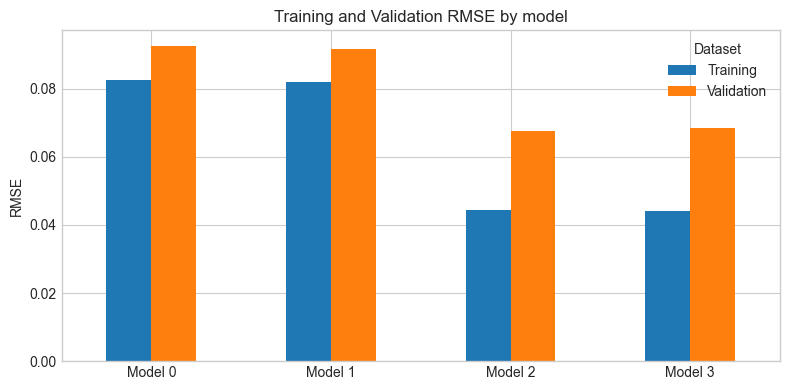

In [13]:
all_model_comparison = pd.concat([comparison_table, model_3_metrics], ignore_index=True)
all_model_comparison[["RMSE", "R2", "Bias"]] = all_model_comparison[["RMSE", "R2", "Bias"]].round(4)

print("Comparison of all models")
display(all_model_comparison)

rmse_plot_df = all_model_comparison.pivot(index="Model", columns="Dataset", values="RMSE")

ax = rmse_plot_df.plot(kind="bar", figsize=(8, 4))
ax.set_ylabel("RMSE")
ax.set_title("Training and Validation RMSE by model")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Model 3 Interpretation

Model 3 fitted separate lag parameters for stomatal opening and closing:

| Parameter | Fitted value | Interpretation |
|---|---:|---|
| `k_open` | 0.0060 | adjustment speed when the Leuning target is above the previous dynamic `gsw` |
| `k_close` | 0.0076 | adjustment speed when the Leuning target is below the previous dynamic `gsw` |

The fitted `k_close` is slightly larger than `k_open`, so in this fitted dataset the model estimated closing to be slightly faster than opening. This was not assumed in advance; both response speeds were estimated from the Training data.

Performance comparison with Model 2:

| Model | Dataset | RMSE | R2 | Bias |
|---|---|---:|---:|---:|
| Model 2 | Training | 0.0519 | 0.7383 | -0.0025 |
| Model 2 | Validation | 0.0759 | 0.5406 | 0.0091 |
| Model 3 | Training | 0.0518 | 0.7391 | -0.0033 |
| Model 3 | Validation | 0.0760 | 0.5395 | 0.0090 |

Model 3 very slightly improved Training performance, but it did not improve Validation RMSE or R2 compared with Model 2. This suggests that the extra asymmetric lag parameters may be capturing small details in the Training data without improving generalization to unseen Validation files. In other words, the current data do not provide strong evidence that asymmetric opening and closing dynamics improve validation performance beyond the simpler dynamic Leuning model.


# Two-Stage Fitting Workflow

Two-stage fitting separates photosynthesis calibration from stomatal conductance calibration. This prevents the photosynthesis parameters from being adjusted only to improve gsw prediction, making the model more physiologically interpretable.

Measured A is used only to calibrate the intermediate photosynthesis sub-model. It is not used directly as an input to predict gsw.

After calibration, all fitted parameters remain fixed during simulation. The model output changes over time because environmental inputs such as Qin, Ca, and VPDleaf change over time. In dynamic models, the state variable gsw_dynamic also changes over time, but the lag parameters remain fixed.


In [14]:
PHOTOSYNTHESIS_STAGE1_BOUNDS = {
    "names": ["Amax", "K", "Rd"],
    "lower": [5, 100, 0.5],
    "upper": [35, 800, 3],
    "initial": [25, 300, 1.5],
}

TWO_STAGE_FIXED_PARAMS = {
    "Gamma": 42,
}

TWO_STAGE_STOMATAL_BOUNDS = {
    "g0": (0, 0.02),
    "gL": (1, 20),
    "D0": (0.5, 5),
    "g_scale": (0.7, 1.0),
    "k_lag": (0.001, 1),
    "k_open": (0.001, 1),
    "k_close": (0.001, 1),
}

TWO_STAGE_INITIAL_GUESSES = {
    "g_scale": 0.9,
}


def _representative_time_series(df, prediction, predicted_col):
    plot_df = df.copy()
    plot_df[predicted_col] = prediction

    if "_file" in plot_df.columns and not plot_df.empty:
        first_file = plot_df["_file"].iloc[0]
        plot_df = plot_df[plot_df["_file"] == first_file].copy()

    if "elapsed" in plot_df.columns:
        x = plot_df["elapsed"] / 3600
        xlabel = "Elapsed time (h)"
    else:
        x = np.arange(len(plot_df))
        xlabel = "Observation index"

    return plot_df, x, xlabel


def fit_photosynthesis_stage1(train_df):
    """Fit Amax, K, and Rd from measured A using Training data only."""
    stage1_df = train_df.copy()

    for col in ["Qin", "A", "elapsed"]:
        if col in stage1_df.columns:
            stage1_df[col] = pd.to_numeric(stage1_df[col], errors="coerce")

    stage1_df = stage1_df.dropna(subset=["Qin", "A"])
    stage1_df = stage1_df[(stage1_df["Qin"] >= 0) & (stage1_df["A"].between(-10, 50))].copy()

    qin = stage1_df["Qin"].to_numpy(dtype=float)
    measured_a = stage1_df["A"].to_numpy(dtype=float)

    def residuals(params):
        a_model = photosynthesis_light_response(qin, *params)
        return np.nan_to_num(a_model - measured_a, nan=1e3, posinf=1e3, neginf=-1e3)

    result = least_squares(
        residuals,
        x0=np.asarray(PHOTOSYNTHESIS_STAGE1_BOUNDS["initial"], dtype=float),
        bounds=(
            np.asarray(PHOTOSYNTHESIS_STAGE1_BOUNDS["lower"], dtype=float),
            np.asarray(PHOTOSYNTHESIS_STAGE1_BOUNDS["upper"], dtype=float),
        ),
        loss="soft_l1",
    )

    A_params = result.x
    Amax, K, Rd = A_params
    A_model = photosynthesis_light_response(qin, Amax, K, Rd)
    metrics = calculate_metrics(measured_a, A_model)

    print("Stage 1 fitted photosynthesis parameters")
    print(f"  Amax: {Amax:.6g}")
    print(f"  K: {K:.6g}")
    print(f"  Rd: {Rd:.6g}")
    print(f"  optimizer cost: {result.cost:.6g}")
    print(f"  function evaluations: {result.nfev}")
    print("\nStage 1 photosynthesis metrics")
    print(f"  RMSE_A: {metrics['RMSE']:.4f}")
    print(f"  R2_A: {metrics['R2']:.4f}")
    print(f"  Bias_A: {metrics['Bias']:.4f}")

    plt.figure(figsize=(6, 6))
    plt.scatter(measured_a, A_model, s=8, alpha=0.25)
    lim_min = min(np.nanmin(measured_a), np.nanmin(A_model))
    lim_max = max(np.nanmax(measured_a), np.nanmax(A_model))
    plt.plot([lim_min, lim_max], [lim_min, lim_max], color="black", linestyle="--", linewidth=1)
    plt.xlabel("Measured A")
    plt.ylabel("A_model")
    plt.title("Stage 1: measured A vs A_model")
    plt.tight_layout()
    plt.show()

    plot_df, x, xlabel = _representative_time_series(stage1_df, A_model, "A_model")
    plt.figure(figsize=(10, 4))
    plt.plot(x, plot_df["A"], label="Measured A", linewidth=1.5)
    plt.plot(x, plot_df["A_model"], label="A_model", linewidth=1.5)
    plt.xlabel(xlabel)
    plt.ylabel("A")
    plt.title("Stage 1: measured A and A_model time series")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return A_params


def _ensure_model_3_parameter_spec():
    if "MODEL_3_SPEC" in globals() and "Model 3" not in PARAMETER_BOUNDS:
        PARAMETER_BOUNDS["Model 3"] = MODEL_3_SPEC


def _two_stage_spec(model_name):
    _ensure_model_3_parameter_spec()
    spec = PARAMETER_BOUNDS[model_name]
    names = list(spec["names"])
    lower = np.asarray(spec["lower"], dtype=float).copy()
    upper = np.asarray(spec["upper"], dtype=float).copy()
    initial = np.asarray(spec["initial"], dtype=float).copy()

    if model_name in ["Model 1", "Model 2", "Model 3"] and "g_scale" not in names:
        scale_lower, scale_upper = TWO_STAGE_STOMATAL_BOUNDS["g_scale"]
        names.append("g_scale")
        lower = np.append(lower, scale_lower)
        upper = np.append(upper, scale_upper)
        initial = np.append(initial, TWO_STAGE_INITIAL_GUESSES["g_scale"])

    for i, name in enumerate(names):
        if name in TWO_STAGE_STOMATAL_BOUNDS:
            lower[i], upper[i] = TWO_STAGE_STOMATAL_BOUNDS[name]
            initial[i] = np.clip(initial[i], lower[i], upper[i])
        if name in PHOTOSYNTHESIS_STAGE1_BOUNDS["names"]:
            a_idx = PHOTOSYNTHESIS_STAGE1_BOUNDS["names"].index(name)
            lower[i] = PHOTOSYNTHESIS_STAGE1_BOUNDS["lower"][a_idx]
            upper[i] = PHOTOSYNTHESIS_STAGE1_BOUNDS["upper"][a_idx]
            initial[i] = PHOTOSYNTHESIS_STAGE1_BOUNDS["initial"][a_idx]

    return {"names": names, "lower": lower, "upper": upper, "initial": initial}


def _two_stage_leuning_target(df, params):
    target_params = [params[name] for name in ["Amax", "K", "Rd", "g0", "gL", "Gamma", "D0"]]
    target = leuning_1995_model(df["Qin"], df["Ca"], df["VPDleaf"], target_params)
    return params.get("g_scale", 1.0) * np.asarray(target, dtype=float)


def predict_two_stage_model(model_name, params, df):
    if model_name == "Model 0":
        return predict_model("Model 0", params_to_array("Model 0", params), df)

    if model_name == "Model 1":
        return _two_stage_leuning_target(df, params)

    output = pd.Series(index=df.index, dtype=float)
    groups = df.groupby("_file", sort=False) if "_file" in df.columns else [(None, df)]

    for _, group in groups:
        target = _two_stage_leuning_target(group, params)
        dynamic = np.empty_like(target)
        if len(target) == 0:
            continue

        dynamic[0] = np.clip(group["gsw"].iloc[0], 0, 0.6)
        for i in range(1, len(target)):
            if model_name == "Model 2":
                k = params["k_lag"]
            elif model_name == "Model 3" and "asymmetric_dynamic_leuning_model" in globals():
                k = params["k_open"] if target[i] > dynamic[i - 1] else params["k_close"]
            else:
                raise ValueError(f"Unknown two-stage model: {model_name}")
            dynamic[i] = dynamic[i - 1] + k * (target[i] - dynamic[i - 1])

        output.loc[group.index] = dynamic

    return output.to_numpy()


def fit_model_two_stage(model_name, train_df, A_params):
    """Fit stomatal parameters while keeping Amax, K, and Rd fixed from Stage 1."""
    spec = _two_stage_spec(model_name)
    names = spec["names"]
    fixed_names = ["Amax", "K", "Rd"]
    fixed_values = dict(zip(fixed_names, A_params))
    fixed_values.update({name: value for name, value in TWO_STAGE_FIXED_PARAMS.items() if name in names})

    free_names = [name for name in names if name not in fixed_values]

    # SciPy requires every optimized lower bound to be strictly below its upper bound.
    # If any parameter is accidentally specified with equal bounds, treat it as fixed.
    equal_bound_names = [
        name for name in free_names
        if np.isclose(spec["lower"][names.index(name)], spec["upper"][names.index(name)])
    ]
    for name in equal_bound_names:
        fixed_values[name] = spec["initial"][names.index(name)]

    free_names = [name for name in names if name not in fixed_values]
    free_indices = [names.index(name) for name in free_names]

    lower_free = spec["lower"][free_indices]
    upper_free = spec["upper"][free_indices]
    initial_free = np.clip(spec["initial"][free_indices], lower_free, upper_free)
    y_obs = train_df["gsw"].to_numpy(dtype=float)

    def build_full_params(free_values):
        param_by_name = dict(fixed_values)
        param_by_name.update(dict(zip(free_names, free_values)))
        return {name: param_by_name[name] for name in names}

    def residuals(free_values):
        full_params = build_full_params(free_values)
        y_pred = predict_two_stage_model(model_name, full_params, train_df)
        residual = y_pred - y_obs
        return np.nan_to_num(residual, nan=1e3, posinf=1e3, neginf=-1e3)

    result = least_squares(
        residuals,
        x0=initial_free,
        bounds=(lower_free, upper_free),
        loss="soft_l1",
    )

    params = build_full_params(result.x)
    return params, result


def evaluate_two_stage_models(params_by_model, train_df, validation_df):
    rows = []
    for model_name, params in params_by_model.items():
        for dataset_name, df in [("Training", train_df), ("Validation", validation_df)]:
            y_pred = predict_two_stage_model(model_name, params, df)
            metrics = calculate_metrics(df["gsw"], y_pred)
            rows.append({"Model": model_name, "Dataset": dataset_name, **metrics})
    return pd.DataFrame(rows)


def plot_two_stage_gsw_predictions(params_by_model, train_df, validation_df):
    for model_name, params in params_by_model.items():
        for dataset_name, df in [("Training", train_df), ("Validation", validation_df)]:
            y_pred = predict_two_stage_model(model_name, params, df)
            plot_observed_vs_predicted(
                df["gsw"],
                y_pred,
                f"Two-stage {model_name}: {dataset_name} observed vs predicted gsw",
            )
            plot_timeseries(
                df,
                y_pred,
                f"Two-stage {model_name}: {dataset_name} time-series observed vs predicted gsw",
            )


Stage 1 fitted photosynthesis parameters
  Amax: 30.287
  K: 398.94
  Rd: 1.59342
  optimizer cost: 32168.3
  function evaluations: 6

Stage 1 photosynthesis metrics
  RMSE_A: 2.7992
  R2_A: 0.9083
  Bias_A: 0.2978


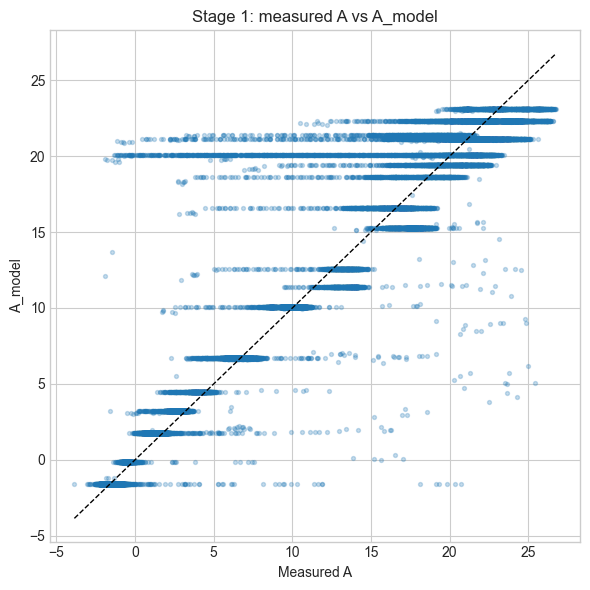

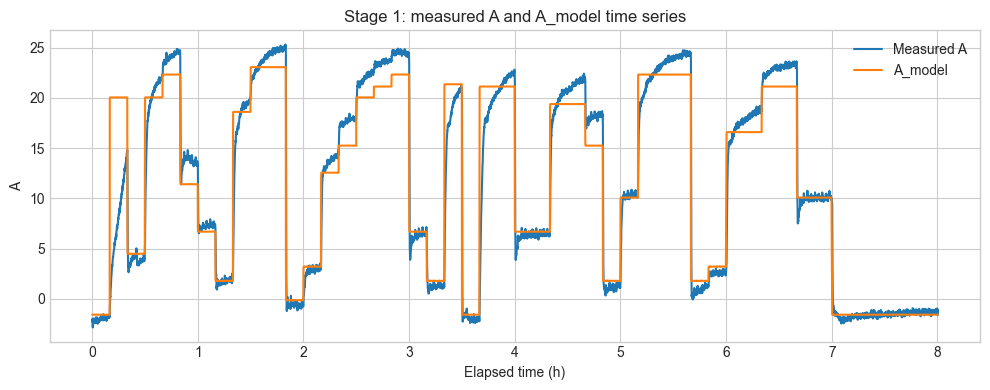


Two-stage Model 0 fitted parameters
  g0: 0.1
  a: 5
  Kq: 16.8769
  D0: 0.0430852
  optimizer cost: 114.249
  function evaluations: 45

Two-stage Model 1 fitted parameters
  Amax: 30.287
  K: 398.94
  Rd: 1.59342
  g0: 0.02
  gL: 16.5084
  Gamma: 42
  D0: 0.5
  optimizer cost: 367.051
  function evaluations: 16

Two-stage Model 2 fitted parameters
  Amax: 30.287
  K: 398.94
  Rd: 1.59342
  g0: 0.02
  gL: 20
  Gamma: 42
  D0: 0.563344
  k_lag: 0.00436115
  optimizer cost: 44.5207
  function evaluations: 29

Two-stage Model 3 fitted parameters
  Amax: 30.287
  K: 398.94
  Rd: 1.59342
  g0: 0.02
  gL: 19.1822
  Gamma: 42
  D0: 0.5
  k_open: 0.00678944
  k_close: 0.00388565
  optimizer cost: 42.2101
  function evaluations: 24

Two-stage model comparison


,Model,Dataset,RMSE,R2,Bias
0,Model 0,Training,0.0827,0.3341,-0.0086
1,Model 0,Validation,0.0925,0.3161,0.0005
2,Model 1,Training,0.1490,-1.1596,-0.0754
3,Model 1,Validation,0.1518,-0.8418,-0.0633
4,Model 2,Training,0.0516,0.7413,-0.0066
5,Model 2,Validation,0.0723,0.5826,0.0060
6,Model 3,Training,0.0502,0.7547,-0.0036
7,Model 3,Validation,0.0707,0.6006,0.0072


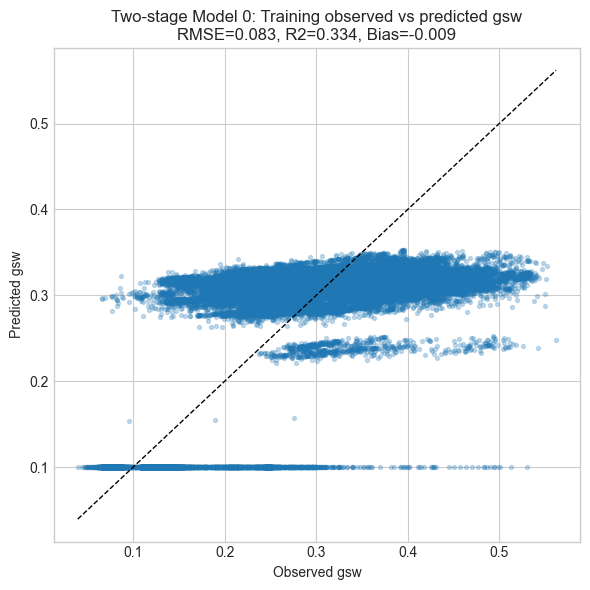

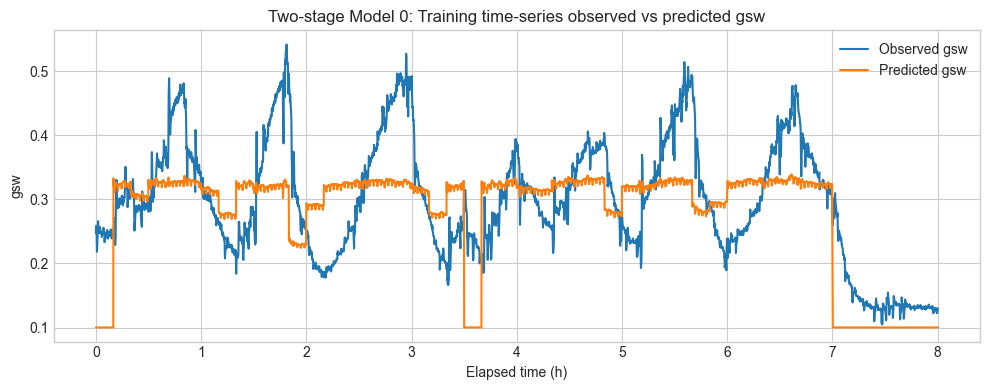

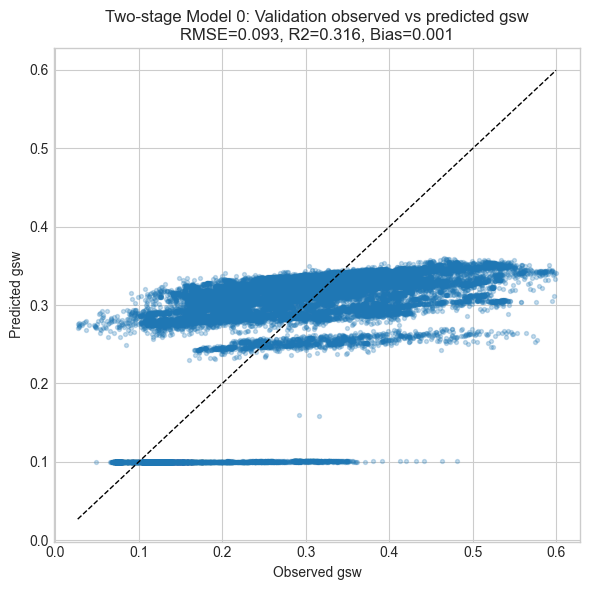

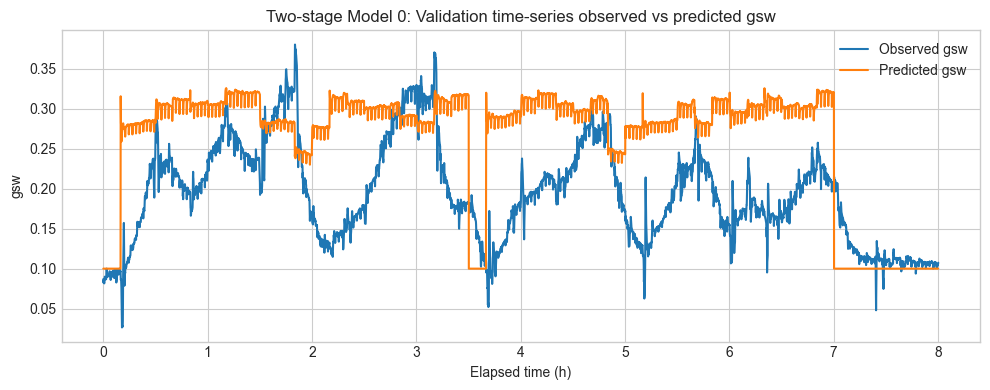

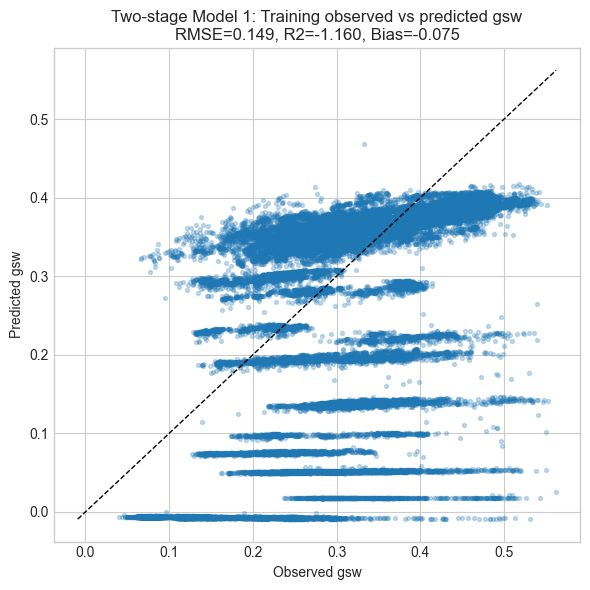

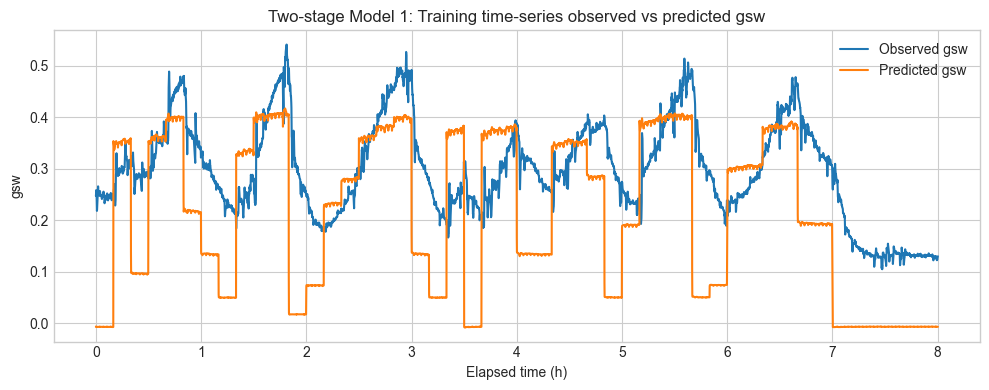

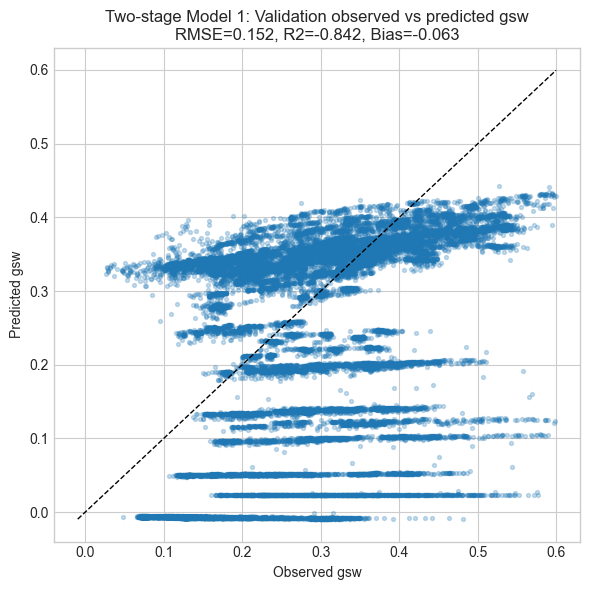

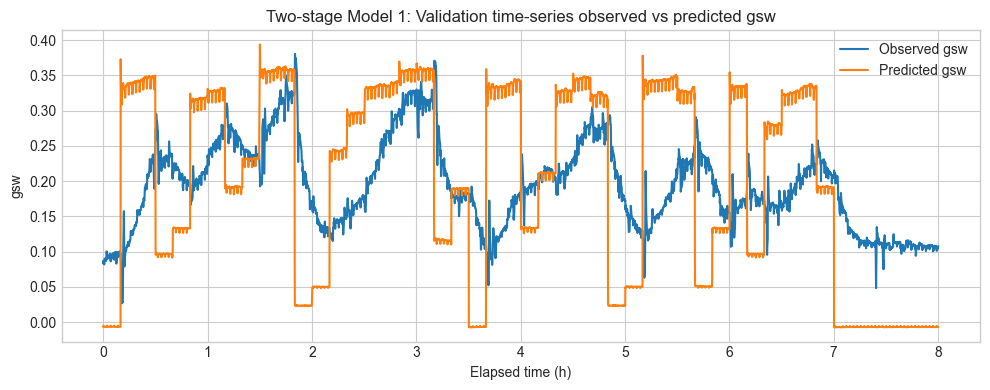

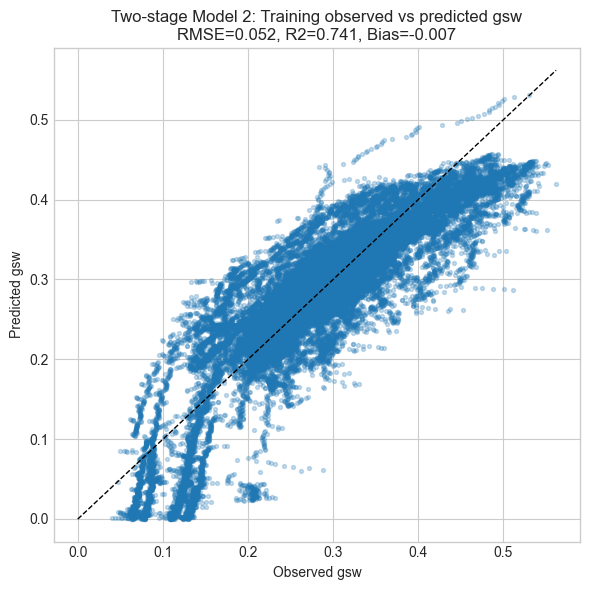

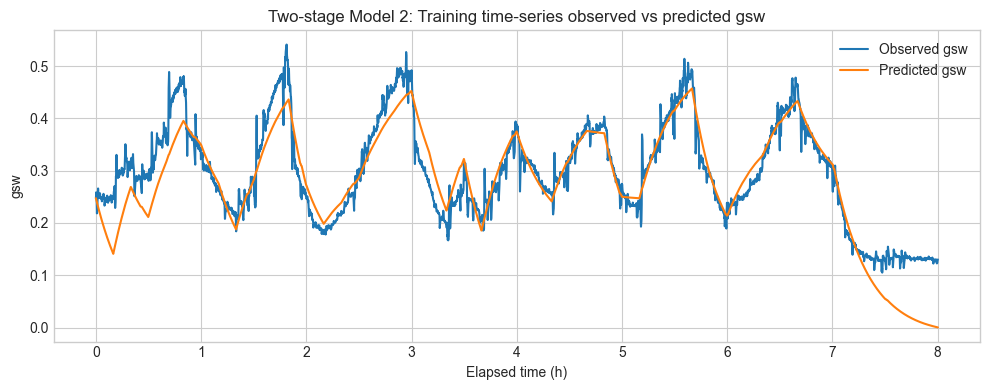

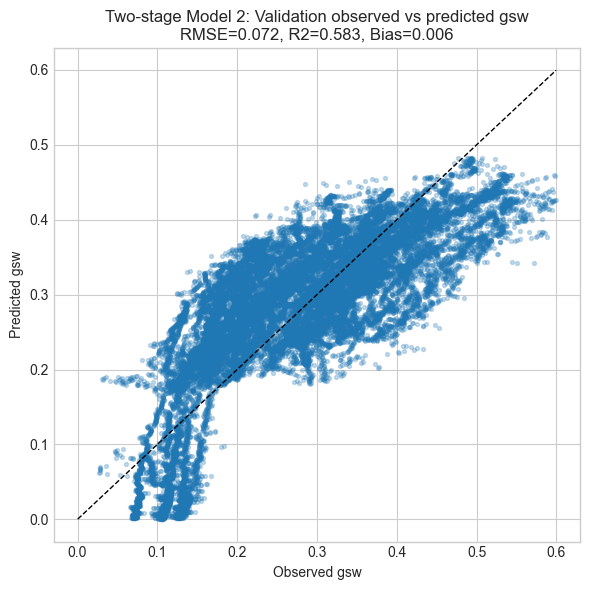

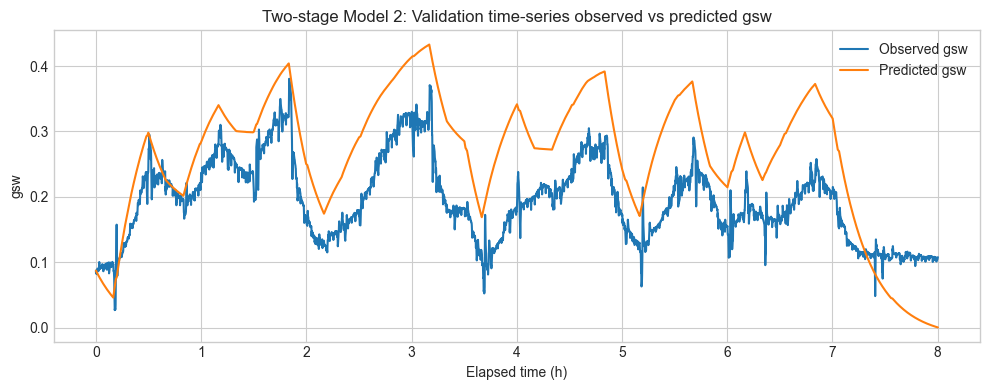

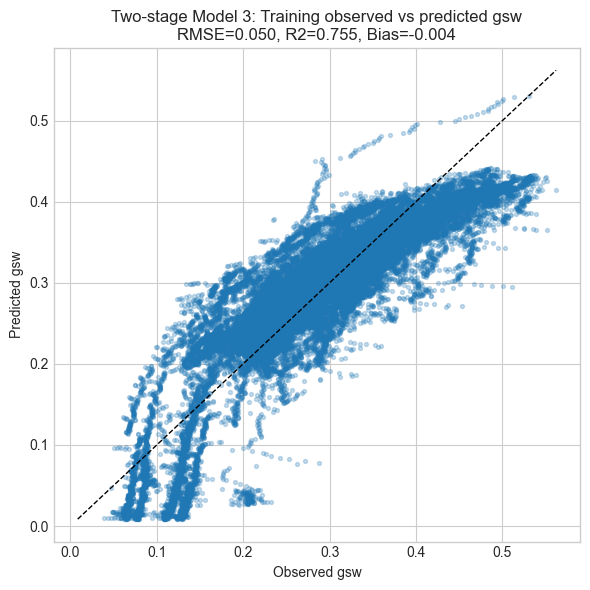

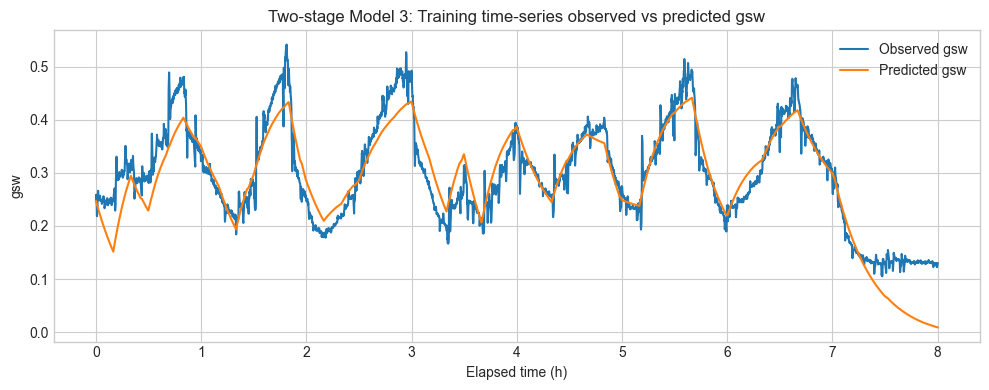

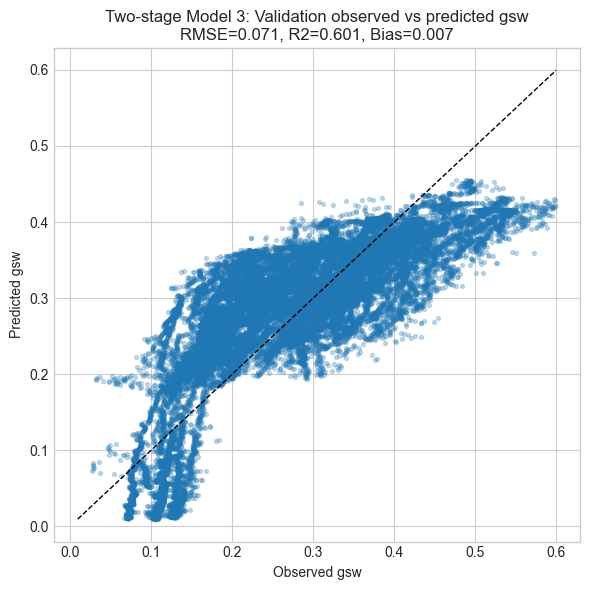

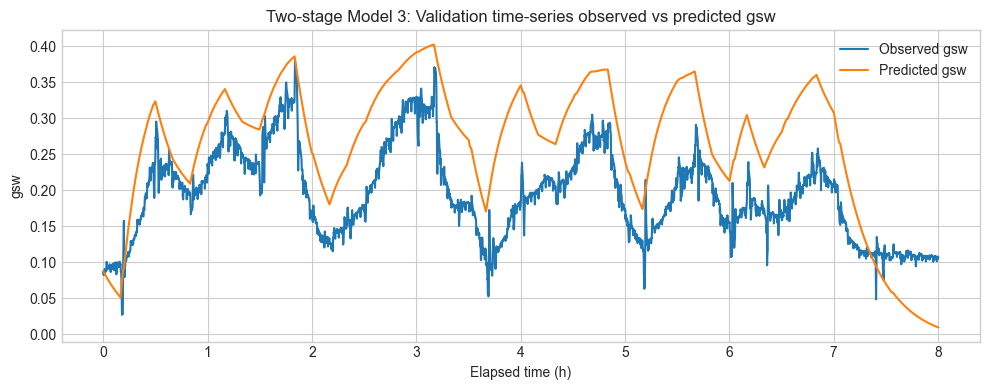

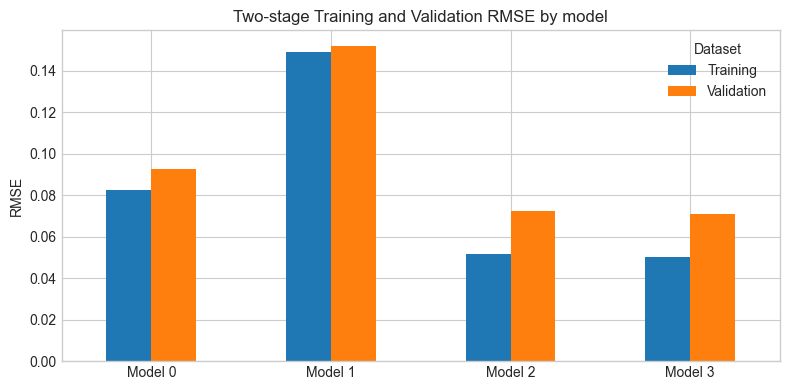


Model 3 lag interpretation
  k_open: 0.00678944
  k_close: 0.00388565
  Opening was estimated faster than closing.


In [15]:
A_params_stage1 = fit_photosynthesis_stage1(train_df)

two_stage_params = {}
two_stage_results = {}

model0_params, model0_result = fit_model("Model 0", train_df)
two_stage_params["Model 0"] = model0_params
two_stage_results["Model 0"] = model0_result

for model_name in ["Model 1", "Model 2"]:
    params, result = fit_model_two_stage(model_name, train_df, A_params_stage1)
    two_stage_params[model_name] = params
    two_stage_results[model_name] = result

if "asymmetric_dynamic_leuning_model" in globals():
    params, result = fit_model_two_stage("Model 3", train_df, A_params_stage1)
    two_stage_params["Model 3"] = params
    two_stage_results["Model 3"] = result

for model_name, params in two_stage_params.items():
    result = two_stage_results[model_name]
    print(f"\nTwo-stage {model_name} fitted parameters")
    for key, value in params.items():
        print(f"  {key}: {value:.6g}")
    print(f"  optimizer cost: {result.cost:.6g}")
    print(f"  function evaluations: {result.nfev}")

two_stage_comparison_table = evaluate_two_stage_models(two_stage_params, train_df, validation_df)
two_stage_comparison_table[["RMSE", "R2", "Bias"]] = two_stage_comparison_table[["RMSE", "R2", "Bias"]].round(4)

print("\nTwo-stage model comparison")
display(two_stage_comparison_table)

plot_two_stage_gsw_predictions(two_stage_params, train_df, validation_df)

rmse_plot_df = two_stage_comparison_table.pivot(index="Model", columns="Dataset", values="RMSE")
ax = rmse_plot_df.plot(kind="bar", figsize=(8, 4))
ax.set_ylabel("RMSE")
ax.set_title("Two-stage Training and Validation RMSE by model")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

if "Model 3" in two_stage_params:
    k_open = two_stage_params["Model 3"]["k_open"]
    k_close = two_stage_params["Model 3"]["k_close"]
    print("\nModel 3 lag interpretation")
    print(f"  k_open: {k_open:.6g}")
    print(f"  k_close: {k_close:.6g}")
    if k_open > k_close:
        print("  Opening was estimated faster than closing.")
    elif k_close > k_open:
        print("  Closing was estimated faster than opening.")
    else:
        print("  Opening and closing were estimated at the same speed.")


## Two-Stage Model Interpretation

If two-stage fitting improves validation performance, it suggests better generalization. If it improves training performance but worsens validation performance, it may indicate overfitting or an overly constrained photosynthesis sub-model.

Model 0 is still fitted with the original one-stage fitting function because it does not use the intermediate A_model. Model 1, Model 2, and Model 3 when available use fixed Amax, K, and Rd from Stage 1, then fit only the stomatal conductance parameters.
